<a href="https://colab.research.google.com/github/KowshiqKatta/Generative-AI/blob/main/LangGraph/subgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

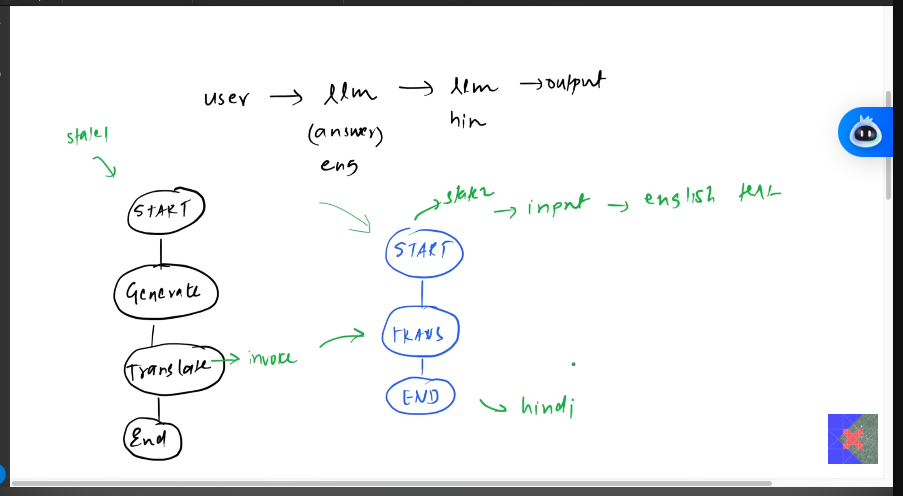

In [4]:
!pip install langchain_openai

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.9 MB/s eta 0:00:00


False

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [6]:
import os

# Replace 'YOUR_OPENAI_API_KEY' with your actual OpenAI API key
os.environ["OPENAI_API_KEY"] = "YOUR-API-KEY"

subgraph_llm = ChatOpenAI(model='gpt-4o')

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

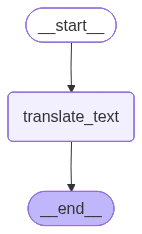

In [15]:
subgraph

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str


In [10]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')

In [11]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [12]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

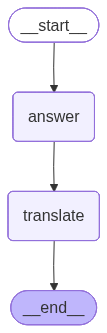

In [14]:
graph = parent_builder.compile()

graph

In [16]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a fundamental branch of physics that deals with the behavior of matter and energy at very small scales, typically at the level of atoms and subatomic particles. It describes how particles such as electrons and photons behave, often in ways that are counterintuitive to classical physics.\n\nKey concepts in quantum physics include:\n\n1. **Wave-Particle Duality**: Particles can exhibit properties of both waves and particles. For example, light can behave as both a wave and a stream of particles (photons).\n\n2. **Quantum Superposition**: Particles can exist in multiple states or locations simultaneously until measured or observed, at which point they "collapse" into a single state.\n\n3. **Quantum Entanglement**: Particles can become entangled, such that the state of one particle is dependent on the state of another, regardless of the distance between them.\n\n4. **Uncertainty Pri